In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

In [2]:
# Final Machine Learning Assignment: Real or Fake Job Listing

#Submitted by:
# Michelle S. (Last ID digits: 3625)
# Or B. (Last ID digits: 5160)

### Problem Description and Dataset
#The goal of this project is to determine whether a job advertisement is real or a scam. This is a **Supervised Learning** problem, and specifically a **Binary Classification** problem.

#Data Challenges (Imbalanced Data) and Quality Metric:
#Our dataset contains approximately 17,880 records, but suffers from a severe imbalance - only about 800 of the jobs are classified as "fake" (an extreme minority).
#In a situation with such significant imbalance, using a standard Accuracy metric is ineffective because the model could receive a high score just by constantly guessing the majority class (real job) without actually learning anything. Therefore, in accordance with the assignment requirements for binary classification problems[cite: 1], we will evaluate the quality of our model using the F1-Score metric exclusively on the main class (the fake jobs).

In [3]:
#import the DataSet
df = pd.read_csv('fake_job_postings.csv')
#displays first 5 rows
display(df.head())

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
#Show the info of the dataset
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function   

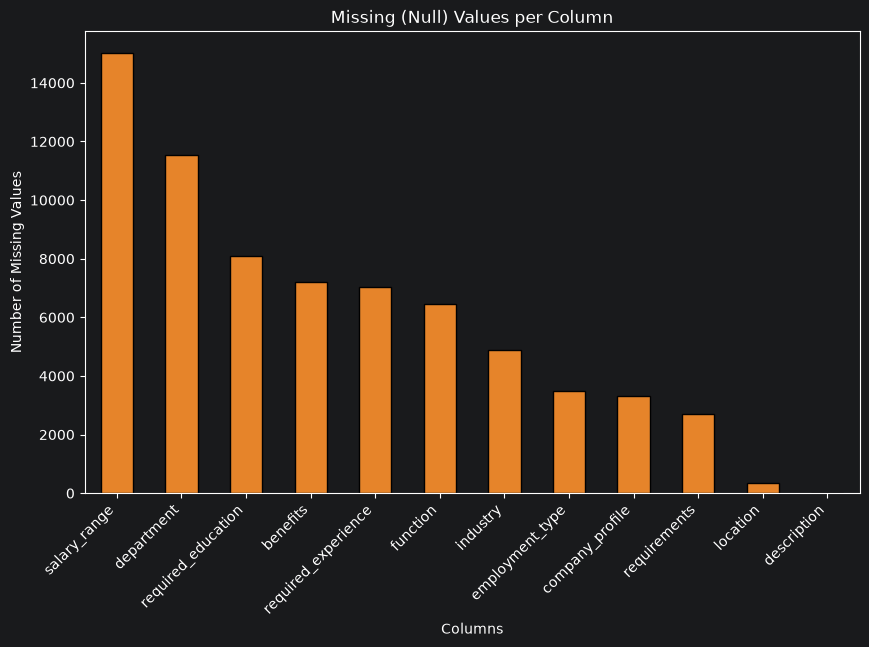

In [5]:
#Visualiztaion of the null values in every given column
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
null_counts = null_counts.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
null_counts.plot(kind='bar', color='#E6842A', edgecolor='black')
plt.title('Missing (Null) Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.show()

In [6]:
#Checking how many as real and how many are fake (with 0 being "Real" and 1 being "Fake"
target_dist = pd.DataFrame({
    'Count': df['fraudulent'].value_counts(),
    'Percentage': (df['fraudulent'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
})
print("\n--- Target Variable Distribution ('fraudulent') ---")
target_dist


--- Target Variable Distribution ('fraudulent') ---


,Count,Percentage
fraudulent,,
0,17014,95.16%
1,866,4.84%


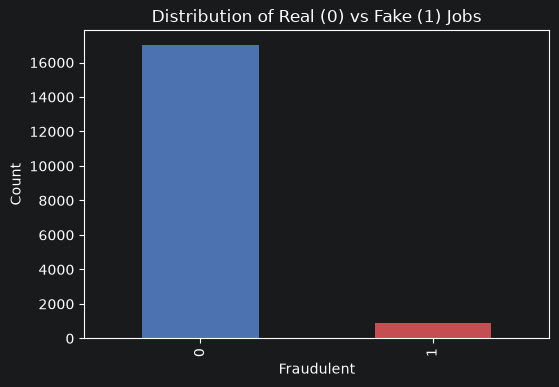

In [7]:
""#We can see that there is much more real jobs then fake ones - 800 fakes and 17,014 real. We shall use the plt to bisulaize it.
plt.figure(figsize=(6, 4))
df['fraudulent'].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Distribution of Real (0) vs Fake (1) Jobs')
plt.xlabel('Fraudulent')
plt.ylabel('Count')
plt.show()

In [8]:
#Now that we understood the DataSet, we can train it. The dataset was not pre-split, so we will split it ourselves. Because of the clear imbalance between the real and fake jobs, we will use the "stratify=y" - which will divide our data so that both the training and testing sets keep the same percentage of class labels as the original DataSet. We will allocate 80% towards training and 20% towards testing.

#First, we will remove the duplicates.

df_clean = df.drop_duplicates()
print (f'removed {len(df) - len(df_clean)} rows')

#Then, we will drop the "fraudulent" column.
X = df.drop(columns=['fraudulent'])
y = df['fraudulent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("--- Train and Test Sets Shapes ---")
print(f"X_train shape: {X_train.shape}") #train should have 80% of dataset
print(f"X_test shape: {X_test.shape}") #test have 20% of dataset
print(f"y_train shape: {y_train.shape}") #same as X, but refers specifically to the "fraudulent" column
print(f"y_test shape: {y_test.shape}")

removed 0 rows
--- Train and Test Sets Shapes ---
X_train shape: (14304, 17)
X_test shape: (3576, 17)
y_train shape: (14304,)
y_test shape: (3576,)


In [9]:
#PART 2 - FEATURE ENGINEERING#

In [10]:
# ==========================================
# Feature Engineering & Preprocessing Steps
# ==========================================
# The dataset contains extensive textual information that algorithms cannot process in raw form
# To manage memory efficiently and convert this data into a valid computational representation, we apply the following 5 data cleansing and vectorization steps:

# 1. Cleaning Null Values: Many columns contain missing data. We replace nulls in text columns with empty strings to prevent errors during vectorization, and fill categorical nulls with "unknown" since missing information can be a predictive trait for fake jobs. We can also see that salary range has more than 80% null values, and will not give us valid idea of real and fake jobs, we decided to drop the column.
# 2. Tokenization: Splits the continuous job descriptions into individual words or tokens.
# 3. Stop-Words Removal: Filters out common words to remove noise, reducing the model's memory load and highlighting the core idea.
# 4. Bag of Words (BoW): Performs the actual vectorization. It converts text into numerical vectors of raw word counts, matching the counting assumptions our from-scratch Multinomial/Bernoulli Naive Bayes implementation is built on.
# 5. N-grams: Captures continuous sequences of words rather than just single words, preserving critical context needed to identify fraudulent phrasing in the text data.

In [11]:
#STEP 1
#IMPORTANT: we clean X_train and X_test separately (not df), because df was already split
#into X_train/X_test in the previous cell - cleaning df after the split does not affect them at all.

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
cat_cols = ['location', 'department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

for split_df in (X_train, X_test):
    split_df[text_cols] = split_df[text_cols].fillna('')
    split_df[cat_cols] = split_df[cat_cols].fillna('Unknown')
    split_df.drop(columns=['salary_range'], inplace=True, errors='ignore') #errors='ignore' so re-running this cell doesn't fail once the column is already dropped

#checking
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])
if X_train.isnull().sum().sum() or X_test.isnull().sum().sum():
    print("Nulls still present!")
else:
    print("No nulls remain in X_train or X_test.")


Series([], dtype: int64)
Series([], dtype: int64)
No nulls remain in X_train or X_test.


In [12]:
#STEP 2 - Tokenization
#We merge the text columns into one field per row, then split that text into individual lowercase word tokens.
#We use a simple regex tokenizer (matches sklearn's own default pattern: alphabetic words of length >= 2) so the result is a plain list of tokens we can inspect before handing it to any vectorizer.
import re

X_train['full_text'] = X_train[text_cols].agg(' '.join, axis=1)
X_test['full_text'] = X_test[text_cols].agg(' '.join, axis=1)

def simple_tokenize(text):
    return re.findall(r"\b[a-zA-Z]{2,}\b", text.lower())

X_train['tokens'] = X_train['full_text'].apply(simple_tokenize)
X_test['tokens'] = X_test['full_text'].apply(simple_tokenize)

print("--- Train Example 1: raw text (first 150 chars) ---")
print(X_train['full_text'].iloc[0][:150])
print("--- Train Example 1: tokens (first 20) ---")
print(X_train['tokens'].iloc[0][:20])

print("\n--- Train Example 2: raw text (first 150 chars) ---")
print(X_train['full_text'].iloc[1][:150])
print("--- Train Example 2: tokens (first 20) ---")
print(X_train['tokens'].iloc[1][:20])


--- Train Example 1: raw text (first 150 chars) ---
Contact Center Representatives Tidewater Finance Co. was established in 1992 for the initial purpose of purchasing, and servicing retail installment c
--- Train Example 1: tokens (first 20) ---
['contact', 'center', 'representatives', 'tidewater', 'finance', 'co', 'was', 'established', 'in', 'for', 'the', 'initial', 'purpose', 'of', 'purchasing', 'and', 'servicing', 'retail', 'installment', 'contracts']

--- Train Example 2: raw text (first 150 chars) ---
Customer Service Associate  Novitex Enterprise Solutions, formerly Pitney Bowes Management Services, delivers innovative document and communications m
--- Train Example 2: tokens (first 20) ---
['customer', 'service', 'associate', 'novitex', 'enterprise', 'solutions', 'formerly', 'pitney', 'bowes', 'management', 'services', 'delivers', 'innovative', 'document', 'and', 'communications', 'management', 'solutions', 'that', 'help']


In [13]:
#STEP 3 - Stop-Words Removal
#Common words ("the", "and", "to", ...) carry no predictive signal and just add noise/memory overhead,
#so we filter them out of the token lists using sklearn's built-in English stop-word list.
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(tokens):
    return [t for t in tokens if t not in ENGLISH_STOP_WORDS]

X_train['tokens_clean'] = X_train['tokens'].apply(remove_stopwords)
X_test['tokens_clean'] = X_test['tokens'].apply(remove_stopwords)

print("--- Train Example 1: tokens before stop-word removal (first 20) ---")
print(X_train['tokens'].iloc[0][:20])
print("--- Train Example 1: tokens after stop-word removal (first 20) ---")
print(X_train['tokens_clean'].iloc[0][:20])

print(f"\nAvg tokens per row before: {X_train['tokens'].apply(len).mean():.1f}")
print(f"Avg tokens per row after:  {X_train['tokens_clean'].apply(len).mean():.1f}")


--- Train Example 1: tokens before stop-word removal (first 20) ---
['contact', 'center', 'representatives', 'tidewater', 'finance', 'co', 'was', 'established', 'in', 'for', 'the', 'initial', 'purpose', 'of', 'purchasing', 'and', 'servicing', 'retail', 'installment', 'contracts']
--- Train Example 1: tokens after stop-word removal (first 20) ---
['contact', 'center', 'representatives', 'tidewater', 'finance', 'established', 'initial', 'purpose', 'purchasing', 'servicing', 'retail', 'installment', 'contracts', 'divisions', 'tidewater', 'credit', 'services', 'providing', 'indirect', 'consumer']

Avg tokens per row before: 372.5
Avg tokens per row after:  230.0


In [14]:
#STEP 4 - Bag of Words (BoW)
#Converts the cleaned tokens into numerical vectors of raw word counts (how many times each word appears in the document). We use raw counts instead of TF-IDF because Multinomial Naive Bayes is built around counting: Multinomial NB models P(word|class) as a word-count frequency, We feed CountVectorizer our already-tokenized lists directly (tokenizer/preprocessor set to identity, token_pattern=None) so it does NOT re-tokenize the raw text - it just counts our tokens.
from sklearn.feature_extraction.text import CountVectorizer

bow_unigram = CountVectorizer(
    tokenizer=lambda tokens: tokens,
    preprocessor=lambda tokens: tokens,
    token_pattern=None,
    max_features=5000
)
X_train_bow_uni = bow_unigram.fit_transform(X_train['tokens_clean'])
X_test_bow_uni = bow_unigram.transform(X_test['tokens_clean'])

print("--- BoW (unigrams only) ---")
print(f"X_train_bow_uni shape: {X_train_bow_uni.shape}")
print(f"X_test_bow_uni shape: {X_test_bow_uni.shape}")
print("\nTrain Example 1 vector (non-zero entries):")
print(X_train_bow_uni[0])


--- BoW (unigrams only) ---
X_train_bow_uni shape: (14304, 5000)
X_test_bow_uni shape: (3576, 5000)

Train Example 1 vector (non-zero entries):
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 181 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 973)	2
  (0, 680)	4
  (0, 3789)	2
  (0, 4567)	8
  (0, 1788)	5
  (0, 1600)	1
  (0, 2280)	1
  (0, 3583)	1
  (0, 3580)	1
  (0, 4071)	1
  (0, 3851)	2
  (0, 2316)	1
  (0, 995)	1
  (0, 1345)	1
  (0, 1095)	4
  (0, 4069)	2
  (0, 3561)	2
  (0, 2259)	2
  (0, 970)	2
  (0, 3082)	1
  (0, 2888)	2
  (0, 390)	1
  (0, 1790)	1
  (0, 3764)	1
  (0, 856)	1
  :	:
  (0, 1575)	1
  (0, 3070)	1
  (0, 1488)	1
  (0, 325)	1
  (0, 3720)	1
  (0, 3620)	1
  (0, 148)	1
  (0, 4082)	1
  (0, 2720)	1
  (0, 4307)	3
  (0, 3760)	1
  (0, 2828)	1
  (0, 714)	1
  (0, 3544)	1
  (0, 2534)	1
  (0, 2234)	1
  (0, 3021)	1
  (0, 1487)	1
  (0, 2235)	1
  (0, 1493)	1
  (0, 2331)	1
  (0, 144)	1
  (0, 4415)	1
  (0, 1538)	1
  (0, 3245)	1


In [15]:
#STEP 5 - N-grams
#Single words alone lose context (e.g. "not" and "guaranteed" separately mean less than the phrase
#"not guaranteed"). We extend the same CountVectorizer to also capture 2-word sequences (bigrams),
#which preserves short phrases that can be characteristic of fraudulent listings.
#This is our FINAL feature representation, used for modeling going forward.
bow = CountVectorizer(
    tokenizer=lambda tokens: tokens,
    preprocessor=lambda tokens: tokens,
    token_pattern=None,
    ngram_range=(1, 2),
    max_features=5000
)
X_train_vec = bow.fit_transform(X_train['tokens_clean'])
X_test_vec = bow.transform(X_test['tokens_clean'])

print("--- BoW with N-grams (unigrams + bigrams) - FINAL ---")
print(f"X_train_vec shape: {X_train_vec.shape}")
print(f"X_test_vec shape: {X_test_vec.shape}")

sample_bigrams = [f for f in bow.get_feature_names_out() if ' ' in f][:10]
print(f"\nExample bigram features learned: {sample_bigrams}")

print("\nTrain Example 1 vector (non-zero entries):")
print(X_train_vec[0])


--- BoW with N-grams (unigrams + bigrams) - FINAL ---
X_train_vec shape: (14304, 5000)
X_test_vec shape: (3576, 5000)

Example bigram features learned: ['abc supply', 'ability adapt', 'ability build', 'ability communicate', 'ability effectively', 'ability learn', 'ability manage', 'ability multi', 'ability prioritize', 'ability work']

Train Example 1 vector (non-zero entries):
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 287 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 895)	2
  (0, 594)	4
  (0, 3728)	2
  (0, 4529)	8
  (0, 1738)	5
  (0, 1547)	1
  (0, 2231)	1
  (0, 3547)	1
  (0, 3543)	1
  (0, 4025)	1
  (0, 3794)	2
  (0, 922)	1
  (0, 1279)	1
  (0, 1005)	4
  (0, 4010)	2
  (0, 3529)	2
  (0, 2202)	2
  (0, 892)	2
  (0, 3048)	1
  (0, 2835)	2
  (0, 321)	1
  (0, 1742)	1
  (0, 3707)	1
  (0, 756)	1
  (0, 2969)	1
  :	:
  (0, 265)	1
  (0, 1429)	1
  (0, 3666)	1
  (0, 3591)	1
  (0, 127)	1
  (0, 2659)	1
  (0, 4264)	1
  (0, 3705)	1
  (0, 2770)	1
  (0, 4262)	1
  (0, 631)	1
 

In [16]:
#STEP 6 - Add Boolean Meta-Features
#On top of the text-based BoW/n-gram features, we attach 3 columns that are already clean 0/1 flags
#and need no encoding: telecommuting, has_company_logo, has_questions. Fake job posts tend to differ from real ones on these (e.g. missing a company logo, no screening questions), so they add cheap extra signal.
from scipy.sparse import hstack, csr_matrix

meta_cols = ['telecommuting', 'has_company_logo', 'has_questions']

X_train_meta = csr_matrix(X_train[meta_cols].values)
X_test_meta = csr_matrix(X_test[meta_cols].values)

X_train_final = hstack([X_train_vec, X_train_meta]).tocsr()
X_test_final = hstack([X_test_vec, X_test_meta]).tocsr()

print("--- Final feature matrix (BoW unigrams+bigrams + 3 boolean meta-features) ---")
print(f"X_train_final shape: {X_train_final.shape}")  #5000 BoW columns + 3 meta columns
print(f"X_test_final shape: {X_test_final.shape}")

--- Final feature matrix (BoW unigrams+bigrams + 3 boolean meta-features) ---
X_train_final shape: (14304, 5003)
X_test_final shape: (3576, 5003)


In [17]:
#-------------STEP 3 - MAKING THE ALGORITHM----------------
#I've decided to use the Multinomial NB one

class MultinomialNB:
    def __init__(self, alpha = 1.0):
        self.alpha = alpha

    def fit (self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.class_log_prior = np.zeros(len(self.classes_))
        self.feature_log_prob_ = np.zeros((len(self.classes_), n_features))
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c] #all rows belonging to class c

